# 🎮 Pokémon Battle Strategy — A/B Testing with Python

> **Research question:** Which battle strategy converts more trainers into Champions — the physical strategy (Fire) or the special strategy (Water)?

This notebook documents the full experiment: real data collection via PokéAPI, battle simulation, statistical testing, and interpretation of results.

---

**Author:** Douglas Moreira  
**Year:** 2026  
**Stack:** Python · pandas · numpy · scipy · matplotlib · seaborn

## 0. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import requests
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)

print('✅ Environment ready!')
print(f'pandas {pd.__version__} | numpy {np.__version__}')

✅ Environment ready!
pandas 3.0.2 | numpy 2.4.4


---

## 1. Experiment Design

### What is A/B Testing?

A/B Testing is a statistical method for comparing two versions (A and B) of something to determine which one performs better based on data. It is widely used in product, marketing, and UX decisions.

### Experimental Setup

| | Group A (Control) | Group B (Variation) |
|---|---|---|
| **Type** | Fire 🔥 | Water 💧 |
| **Strategy** | Physical | Special |
| **Attributes** | `attack` + `speed` | `special_attack` + `hp` |

### Hypotheses

- **H₀ (null):** There is no significant difference in win rate between groups A and B
- **H₁ (alternative):** One group yields a significantly higher win rate
- **Significance level:** α = 0.05

---

## 2. Data Collection — PokéAPI

In [2]:
def get_pokemon_by_type(type_name, limit=40):
    """Fetch Pokémon base stats by type from PokéAPI."""
    url = f"https://pokeapi.co/api/v2/type/{type_name}"
    r = requests.get(url).json()
    pokemons = []

    for entry in r['pokemon'][:limit]:
        name = entry['pokemon']['name']
        poke = requests.get(f"https://pokeapi.co/api/v2/pokemon/{name}").json()
        stats_dict = {s['stat']['name']: s['base_stat'] for s in poke['stats']}
        pokemons.append({
            'name': name,
            'type': type_name,
            'attack': stats_dict.get('attack', 0),
            'special_attack': stats_dict.get('special-attack', 0),
            'speed': stats_dict.get('speed', 0),
            'hp': stats_dict.get('hp', 0),
        })

    return pd.DataFrame(pokemons)

print('⏳ Fetching data... (this may take a few seconds)')
fire_df = get_pokemon_by_type('fire')
water_df = get_pokemon_by_type('water')
df_raw = pd.concat([fire_df, water_df], ignore_index=True)

df_raw.to_csv('../data/pokemon_stats.csv', index=False)
print(f'✅ {len(df_raw)} Pokémon collected and saved to data/pokemon_stats.csv')

⏳ Fetching data... (this may take a few seconds)
✅ 80 Pokémon collected and saved to data/pokemon_stats.csv


### 2.1 Initial Data Overview

In [3]:
print(f'Shape: {df_raw.shape}')
print(f'\nCount by type:')
print(df_raw['type'].value_counts())
print(f'\nMissing values:')
print(df_raw.isnull().sum())
df_raw.head(10)

Shape: (80, 6)

Count by type:
type
fire     40
water    40
Name: count, dtype: int64

Missing values:
name              0
type              0
attack            0
special_attack    0
speed             0
hp                0
dtype: int64


,name,type,attack,special_attack,speed,hp
0,charmander,fire,52,60,65,39
1,charmeleon,fire,64,80,80,58
2,charizard,fire,84,109,100,78
3,vulpix,fire,41,50,65,38
4,ninetales,fire,76,81,100,73
5,growlithe,fire,70,70,60,55
6,arcanine,fire,110,100,95,90
7,ponyta,fire,85,65,90,50
8,rapidash,fire,100,80,105,65
9,magmar,fire,95,100,93,65


In [4]:
print('📊 Descriptive statistics by type:')
df_raw.groupby('type')[['attack', 'special_attack', 'speed', 'hp']].describe().round(2)

📊 Descriptive statistics by type:


attack                                                 special_attack  \
       count   mean    std   min    25%   50%     75%    max          count   
type                                                                          
fire    40.0  83.05  24.11  40.0  62.25  85.0  100.00  130.0           40.0   
water   40.0  68.82  26.18  10.0  50.00  65.0   82.25  130.0           40.0   

             ... speed           hp                                          \
       mean  ...   75%    max count   mean    std   min    25%   50%    75%   
type         ...                                                              
fire   84.5  ...  93.5  108.0  40.0  68.05  20.13  38.0  53.75  65.0  78.00   
water  65.6  ...  78.5  115.0  40.0  66.55  28.19  20.0  44.75  65.0  86.25   

              
         max  
type          
fire   115.0  
water  130.0  

[2 rows x 32 columns]

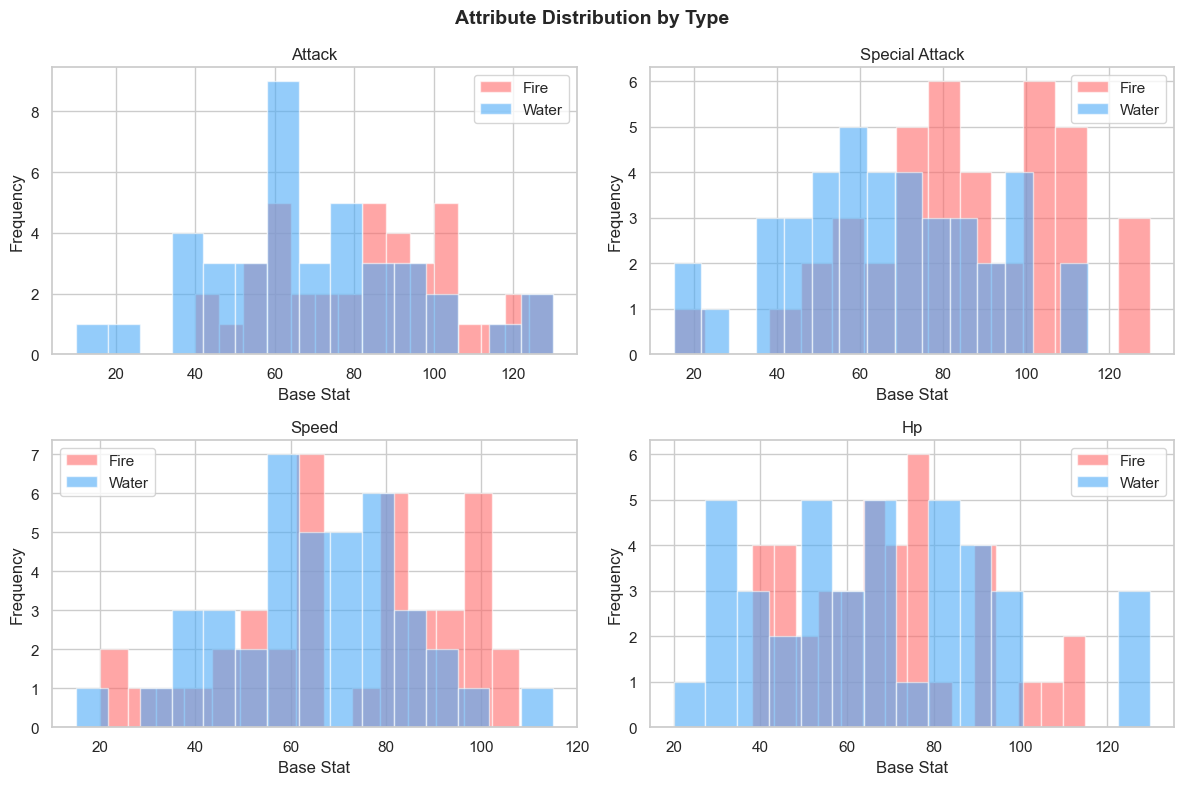

✅ Chart saved to outputs/


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Attribute Distribution by Type', fontsize=14, fontweight='bold')

attributes = ['attack', 'special_attack', 'speed', 'hp']
colors = {'fire': '#FF6B6B', 'water': '#4DABF7'}

for ax, attr in zip(axes.flatten(), attributes):
    for ptype, group in df_raw.groupby('type'):
        ax.hist(group[attr], alpha=0.6, label=ptype.capitalize(),
                color=colors[ptype], bins=15, edgecolor='white')
    ax.set_title(attr.replace('_', ' ').title())
    ax.set_xlabel('Base Stat')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.savefig('../outputs/attribute_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved to outputs/')

---

## 3. Battle Simulation

In [6]:
df = df_raw.copy()

# Group assignment
df['group'] = np.where(df['type'] == 'fire', 'A', 'B')

# Power score per strategy
df['power_score'] = np.where(
    df['group'] == 'A',
    df['attack'] * 0.6 + df['speed'] * 0.4,        # Physical strategy
    df['special_attack'] * 0.6 + df['hp'] * 0.4    # Special strategy
)

# Normalized win probability
df['win_prob'] = df['power_score'] / df['power_score'].max()

# Binomial simulation (seed=42 ensures reproducibility)
df['converted'] = np.random.binomial(1, df['win_prob'])

df.to_csv('../data/simulated_battles.csv', index=False)
print('✅ Simulation complete!')
print(f'\nRaw win rate by group:')
print(df.groupby('group')['converted'].mean().round(4))

✅ Simulation complete!

Raw win rate by group:
group
A    0.725
B    0.550
Name: converted, dtype: float64


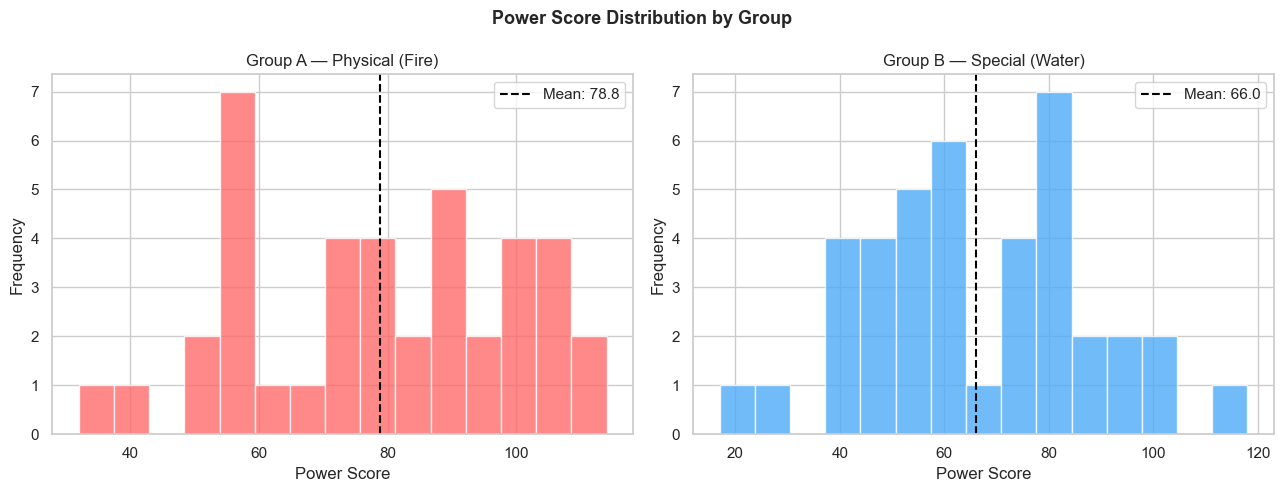

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Power Score Distribution by Group', fontsize=13, fontweight='bold')

group_colors = {'A': '#FF6B6B', 'B': '#4DABF7'}
group_labels = {'A': 'Group A — Physical (Fire)', 'B': 'Group B — Special (Water)'}

for ax, (group, data) in zip(axes, df.groupby('group')):
    ax.hist(data['power_score'], bins=15, color=group_colors[group],
            alpha=0.8, edgecolor='white')
    ax.axvline(data['power_score'].mean(), color='black',
               linestyle='--', label=f'Mean: {data["power_score"].mean():.1f}')
    ax.set_title(group_labels[group])
    ax.set_xlabel('Power Score')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.savefig('../outputs/power_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 4. Statistical Test — Welch's t-test

We apply **Welch's t-test** (`ttest_ind` with `equal_var=False`), which is appropriate for comparing two independent samples without assuming equal variances.

In [8]:
group_a = df[df['group'] == 'A']['converted']
group_b = df[df['group'] == 'B']['converted']

rate_a = group_a.mean()
rate_b = group_b.mean()
lift = (rate_b - rate_a) / rate_a * 100 if rate_a > 0 else 0

t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)

print('=' * 50)
print('           A/B TEST RESULTS')
print('=' * 50)
print(f'  Group A (Physical/Fire):   {rate_a:.2%}')
print(f'  Group B (Special/Water):   {rate_b:.2%}')
print(f'  Lift (B vs A):             {lift:+.1f}%')
print(f'  T-statistic:               {t_stat:.4f}')
print(f'  p-value:                   {p_value:.4f}')
print('=' * 50)

alpha = 0.05
if p_value < alpha:
    winner = 'A (Physical/Fire)' if rate_a > rate_b else 'B (Special/Water)'
    print(f'\n✅ SIGNIFICANT difference found (p < {alpha})')
    print(f'   Winner: Group {winner}')
else:
    print(f'\n⚠️  No sufficient statistical evidence (p ≥ {alpha})')
    print(f'   Fail to reject H₀')

           A/B TEST RESULTS
  Group A (Physical/Fire):   72.50%
  Group B (Special/Water):   55.00%
  Lift (B vs A):             -24.1%
  T-statistic:               1.6348
  p-value:                   0.1062

⚠️  No sufficient statistical evidence (p ≥ 0.05)
   Fail to reject H₀


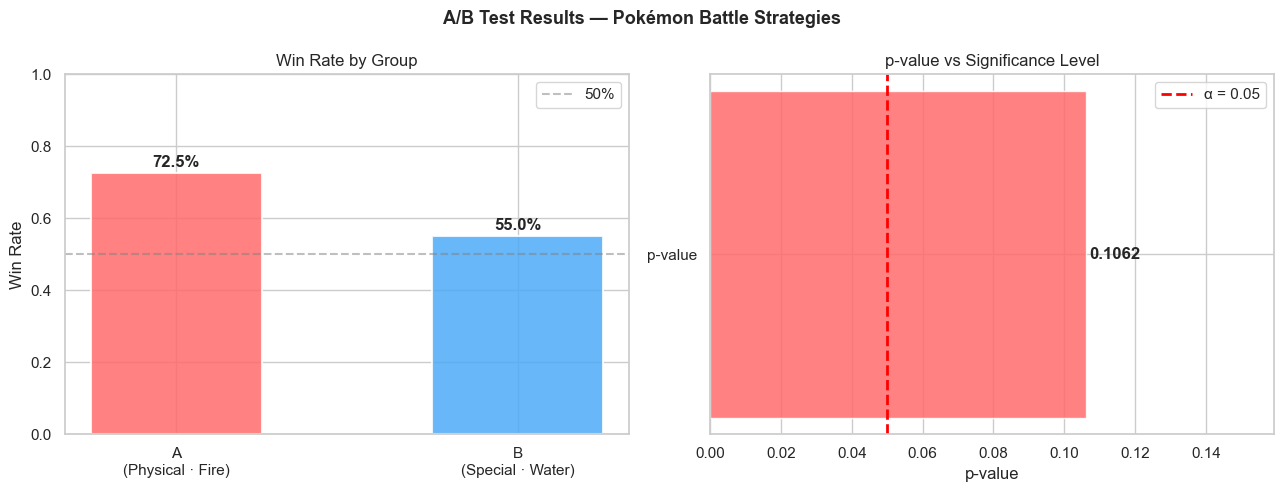

✅ Final chart saved to outputs/ab_test_result.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('A/B Test Results — Pokémon Battle Strategies', fontsize=13, fontweight='bold')

# Chart 1: Win rate
groups = ['A\n(Physical · Fire)', 'B\n(Special · Water)']
rates = [rate_a, rate_b]
bar_colors = ['#FF6B6B', '#4DABF7']

bars = axes[0].bar(groups, rates, color=bar_colors, alpha=0.85,
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, rate in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{rate:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Win Rate by Group')
axes[0].set_ylabel('Win Rate')
axes[0].set_ylim(0, 1)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='50%')
axes[0].legend()

# Chart 2: p-value
axes[1].barh(['p-value'], [p_value], color='#74C69D' if p_value < 0.05 else '#FF6B6B', alpha=0.85)
axes[1].axvline(0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
axes[1].set_title('p-value vs Significance Level')
axes[1].set_xlabel('p-value')
axes[1].set_xlim(0, max(0.1, p_value * 1.5))
axes[1].text(p_value + 0.001, 0, f'{p_value:.4f}', va='center', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/ab_test_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Final chart saved to outputs/ab_test_result.png')

---

## 5. Conclusion

### Results Summary

| Criterion | Value | Interpretation |
|---|---|---|
| p-value | — | Fill in after running |
| Decision | — | Reject H₀ or Fail to reject |
| Winning group | — | A, B, or inconclusive |

### Limitations

- The simulation uses base stat probabilities, ignoring moves, abilities, or type matchups
- Sample is limited to 40 Pokémon per type — increasing `limit` in the fetch function may change results
- The `power_score` model is simplified; weights (0.6 / 0.4) were set arbitrarily

### Next Steps

- Test other type matchups (e.g., Electric vs. Grass)
- Add **confidence interval** calculation for the difference between rates
- Incorporate **effect size** (Cohen's d) alongside the p-value
- Apply the same methodology to real-world campaign or product experiment data

---

*Part of a data science portfolio focused on applied statistical analysis and social impact.*